# Objective Function Landscape Analysis

This notebook performs a systematic investigation of the lightcurve inversion
objective function landscape to understand:

1. **1D slices**: How does the objective vary when changing one parameter at a time?
2. **2D slices**: Are there correlations, ridges, or valleys between parameter pairs?
3. **Gradient/Hessian analysis**: How well-conditioned is the problem at the solution?
4. **Summary**: Is global search necessary, or would local optimization suffice?

This analysis uses the same Intelsat 901 test case as notebook 03 for comparability.

---
## Setup

Reuse the same configuration and synthetic data generation from notebook 03.

In [1]:
import sys
from pathlib import Path
import time
import os

import numpy as np
import matplotlib.pyplot as plt

# Project Root
if '__file__' in globals():
    PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent
else:
    PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# Import config and IO modules
from src.config.rso_config_manager import RSO_ConfigManager
from src.io.stl_loader import STLLoader

# Import SPICE handler
from src.spice.spice_handler import SpiceHandler

# Import computation modules
from src.computation.brdf import BRDFManager, BRDFCalculator
from src.computation.observation_geometry import compute_observation_geometry
from src.computation import compute_inertia_from_config

# Import articulation module for fixed component angles
from src.articulation import compute_rotation_matrices_from_angles

# Import dynamics and inversion modules
from src.dynamics import propagate_attitude
from src.inversion import (
    ObjectiveFunction,
    axis_angle_to_quaternion,
    quaternion_to_axis_angle,
)

# Import for forward model
from src.computation.shadow_engine import compute_shadows
from src.computation.lightcurve_generator import generate_lightcurves

print(f"Project root: {PROJECT_ROOT}")
print("Imports successful!")

Project root: /var/home/girishlikesbutter/projects/lcas_v1.0
Imports successful!


/var/home/girishlikesbutter/projects/lcas_v1.0/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Load Intelsat 901 Configuration (Same as Notebook 03)

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================
config_path = "intelsat_901/intelsat_901_config.yaml"

# Number of observation points (same as notebook 03)
n_observations = 50

# Observer/Ground Station SPICE ID
OBSERVER_ID = 399999

# Load RSO configuration
config_manager = RSO_ConfigManager(PROJECT_ROOT)
config = config_manager.load_config(config_path)

# Get paths from configuration
metakernel_path = config_manager.get_metakernel_path(config)
output_dir = config_manager.get_output_directory(config)

# Use configuration values
satellite_id = config.spice_config.satellite_id
start_time_utc = config.simulation_defaults.start_time
end_time_utc = config.simulation_defaults.end_time

print("=" * 70)
print("OBJECTIVE FUNCTION LANDSCAPE ANALYSIS - Intelsat 901")
print("=" * 70)
print(f"\nConfiguration: {config.name}")
print(f"Observations: {n_observations}")

OBJECTIVE FUNCTION LANDSCAPE ANALYSIS - Intelsat 901

Configuration: Intelsat 901 
Observations: 50


In [3]:
# Load satellite model from STL files
print(f"\nLoading {config.name} satellite model...")
satellite = STLLoader.create_satellite_from_stl_config(
    config=config,
    config_manager=config_manager
)

# Set up BRDF materials
brdf_manager = BRDFManager(config)
brdf_calc = BRDFCalculator()
brdf_calc.update_satellite_brdf_with_manager(satellite, brdf_manager)

print(f"Model loaded: {satellite.name}")
print(f"  Components: {len(satellite.components)}")
total_facets = sum(len(comp.facets) for comp in satellite.components if comp.facets)
print(f"  Total facets: {total_facets:,}")


Loading Intelsat 901  satellite model...
Model loaded: Intelsat 901 
  Components: 5
  Total facets: 3,840


---
## 2. Fixed Articulation Configuration

In [4]:
# Same fixed angles as notebook 03
SOLAR_PANEL_ANGLE_DEG = 0.0
ANTENNA_DISH_ANGLE_DEG = 15.0

print("Fixed articulation configuration:")
print(f"  Solar panels (SP_North, SP_South): {SOLAR_PANEL_ANGLE_DEG}°")
print(f"  Antenna dishes (AD_East, AD_West): {ANTENNA_DISH_ANGLE_DEG}°")

Fixed articulation configuration:
  Solar panels (SP_North, SP_South): 0.0°
  Antenna dishes (AD_East, AD_West): 15.0°


---
## 3. Calculate Inertia Tensor

In [5]:
# Same component masses as notebook 03
component_masses = {
    'Bus': 1532.0,
    'SP_North': 170.0,
    'SP_South': 170.0,
    'AD_East': 50.0,
    'AD_West': 50.0,
}

# Calculate inertia tensor
inertia_result = compute_inertia_from_config(
    config=config,
    config_manager=config_manager,
    masses=component_masses,
    articulation_angles={'SP_North': 0.0, 'SP_South': 0.0}
)

inertia_tensor = inertia_result.inertia_tensor
print(f"Inertia tensor computed:")
print(f"  Principal moments: {inertia_result.principal_moments}")

Using default articulation angle 15.0° for component 'AD_East' (has articulation capability but no angle specified)
Using default articulation angle 15.0° for component 'AD_West' (has articulation capability but no angle specified)


Inertia tensor computed:
  Principal moments: [ 7749.01467225 37985.15566495 38305.70560133]


---
## 4. Initialize SPICE and Compute Observation Geometry

In [6]:
# Initialize SPICE
print("Initializing SPICE...")
spice_handler = SpiceHandler()
spice_handler.load_metakernel_programmatically(str(metakernel_path))

# Generate time series
start_et = spice_handler.utc_to_et(start_time_utc)
end_et = spice_handler.utc_to_et(end_time_utc)
epochs = np.linspace(start_et, end_et, n_observations)

print(f"Time range: {start_time_utc} to {end_time_utc}")
print(f"Observations: {n_observations}")

# Relative observation times starting from 0
observation_times = epochs - epochs[0]

Using legacy metakernel format. Consider updating to v2 format with project-root relative paths for better portability.


Initializing SPICE...
Time range: 2020-02-05T10:00:00 to 2020-02-05T16:00:00
Observations: 50


In [7]:
# Compute observation geometry using SPICE
print("Computing observation geometry...")
geometry_data = compute_observation_geometry(
    epochs=epochs,
    satellite_id=satellite_id,
    observer_id=OBSERVER_ID,
    spice_handler=spice_handler,
    config=config
)

# Extract J2000 positions
sun_positions_j2000 = geometry_data['sun_positions']
observer_positions_j2000 = geometry_data['obs_positions']
satellite_positions_j2000 = geometry_data['sat_positions']
observer_distances = geometry_data['observer_distances']

print(f"Geometry computed: {n_observations} observations")
print(f"Observer distance range: {observer_distances.min():.0f} - {observer_distances.max():.0f} km")

Computing observation geometry...
Geometry computed: 50 observations
Observer distance range: 38597 - 38657 km


In [8]:
# Create fixed articulation matrices
fixed_articulation_angles = {
    'SP_North': np.full(n_observations, SOLAR_PANEL_ANGLE_DEG),
    'SP_South': np.full(n_observations, SOLAR_PANEL_ANGLE_DEG),
    'AD_East': np.full(n_observations, ANTENNA_DISH_ANGLE_DEG),
    'AD_West': np.full(n_observations, ANTENNA_DISH_ANGLE_DEG),
}

articulation_matrices = compute_rotation_matrices_from_angles(
    fixed_articulation_angles, satellite
)

print("Articulation matrices created")

Articulation matrices created


---
## 5. Define True Attitude Parameters (Same as Notebook 03)

In [9]:
# True initial quaternion (same as notebook 03)
true_axis = np.array([0.6, 0.3, 0.8])
true_axis /= np.linalg.norm(true_axis)
true_angle_deg = 45.0
true_angle_rad = np.deg2rad(true_angle_deg)

# Construct quaternion (scalar-first: w, x, y, z)
true_q0 = np.array([
    np.cos(true_angle_rad / 2),
    np.sin(true_angle_rad / 2) * true_axis[0],
    np.sin(true_angle_rad / 2) * true_axis[1],
    np.sin(true_angle_rad / 2) * true_axis[2],
])

# True initial angular velocity (rad/s in body frame)
true_omega_deg_per_s = np.array([0.005, -0.003, 0.05])
true_omega0 = np.deg2rad(true_omega_deg_per_s)

# Convert to axis-angle representation
true_axis_angle = quaternion_to_axis_angle(true_q0)

# Store as combined parameter vector for slicing
# Format: [axis_angle_x, axis_angle_y, axis_angle_z, omega_x, omega_y, omega_z]
true_params = np.concatenate([true_axis_angle, true_omega0])

print("True attitude parameters:")
print(f"  Axis-angle (rad): {true_axis_angle}")
print(f"  Axis-angle (deg): {np.rad2deg(true_axis_angle)}")
print(f"  Angular velocity (deg/s): {np.rad2deg(true_omega0)}")
print(f"\nCombined parameter vector (for slicing):")
print(f"  true_params = {true_params}")

True attitude parameters:
  Axis-angle (rad): [0.451365  0.2256825 0.60182  ]
  Axis-angle (deg): [25.8613097  12.93065485 34.48174627]
  Angular velocity (deg/s): [ 0.005 -0.003  0.05 ]

Combined parameter vector (for slicing):
  true_params = [ 4.51365003e-01  2.25682502e-01  6.01820004e-01  8.72664626e-05
 -5.23598776e-05  8.72664626e-04]


---
## 6. Generate Synthetic Lightcurve

In [10]:
print("\nGenerating synthetic lightcurve with true parameters...")
print("  Mode: TUMBLING with inertia tensor")
print("  Shadows: ENABLED")

# Propagate true attitude using tumbling dynamics
true_quaternions, true_omega_history = propagate_attitude(
    q0=true_q0,
    omega0=true_omega0,
    times=observation_times,
    mode="tumbling",
    inertia_tensor=inertia_tensor,
)

print(f"  Attitude propagated: {len(true_quaternions)} epochs")


Generating synthetic lightcurve with true parameters...
  Mode: TUMBLING with inertia tensor
  Shadows: ENABLED
  Attitude propagated: 50 epochs


In [11]:
# Create a temporary ObjectiveFunction to compute body-frame vectors
objective_temp = ObjectiveFunction(
    satellite=satellite,
    observation_times=observation_times,
    observed_lightcurve=np.zeros(n_observations),  # placeholder
    sun_positions_j2000=sun_positions_j2000,
    observer_positions_j2000=observer_positions_j2000,
    satellite_positions_j2000=satellite_positions_j2000,
    observer_distances=observer_distances,
    compute_shadows_flag=True,
    articulation_matrices=articulation_matrices,
    mode="tumbling",
    inertia_tensor=inertia_tensor,
)

# Get body-frame vectors from propagated attitude
k1_vectors, k2_vectors = objective_temp._compute_body_frame_vectors(true_quaternions)

In [12]:
# Compute shadows with ray tracing
print("Computing shadows...")
lit_status_dict = compute_shadows(
    satellite=satellite,
    k1_vectors=k1_vectors,
    explicit_component_matrices=articulation_matrices,
    show_progress=True,
)

Computing shadows...


Computing shadows: 100%|███████████████████████████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.34epoch/s]


In [13]:
# Generate true lightcurve
print("Generating lightcurve...")
true_lightcurve, total_flux, _, _, _, _ = generate_lightcurves(
    facet_lit_status_dict=lit_status_dict,
    k1_vectors_array=k1_vectors,
    k2_vectors_array=k2_vectors,
    observer_distances=observer_distances,
    satellite=satellite,
    epochs=epochs,
    pre_computed_matrices=articulation_matrices,
    generate_no_shadow=False,
    animate=False,
    show_progress=True,
)

print(f"True lightcurve range: [{true_lightcurve.min():.2f}, {true_lightcurve.max():.2f}] mag")

Generating lightcurve...


Generating light curves: 100%|███████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 3290.37epoch/s]

True lightcurve range: [7.97, 16.99] mag


In [14]:
# Add synthetic noise (same as notebook 03)
np.random.seed(42)
noise_sigma = 0.05
observed_lightcurve = true_lightcurve + np.random.normal(0, noise_sigma, n_observations)

print(f"\nAdded Gaussian noise (sigma = {noise_sigma} mag)")
print(f"Observed lightcurve range: [{observed_lightcurve.min():.2f}, {observed_lightcurve.max():.2f}] mag")


Added Gaussian noise (sigma = 0.05 mag)
Observed lightcurve range: [8.00, 17.00] mag


---
## 7. Create ObjectiveFunction for Landscape Analysis

In [15]:
# Create the objective function for landscape analysis
# This is the function we will slice through to understand the landscape
objective_fn = ObjectiveFunction(
    satellite=satellite,
    observation_times=observation_times,
    observed_lightcurve=observed_lightcurve,
    sun_positions_j2000=sun_positions_j2000,
    observer_positions_j2000=observer_positions_j2000,
    satellite_positions_j2000=satellite_positions_j2000,
    observer_distances=observer_distances,
    compute_shadows_flag=True,  # Use full physics model
    articulation_matrices=articulation_matrices,
    mode="tumbling",
    inertia_tensor=inertia_tensor,
)

# Verify the objective value at true parameters
obj_at_true = objective_fn.evaluate(true_params)
print(f"\nObjectiveFunction created for landscape analysis")
print(f"  Objective value at true parameters: {obj_at_true:.6f}")
print(f"  (This should be close to chi-squared of noise-only residuals)")


ObjectiveFunction created for landscape analysis
  Objective value at true parameters: 0.002263
  (This should be close to chi-squared of noise-only residuals)


---
## Setup Complete

We now have:
- `objective_fn`: The ObjectiveFunction instance for landscape analysis
- `true_params`: The 6-parameter vector [axis_angle_x, axis_angle_y, axis_angle_z, omega_x, omega_y, omega_z]
- `observed_lightcurve`: Synthetic observations with noise
- `noise_sigma`: The noise level (0.05 mag)

The next notebooks (US-003 onwards) will add:
- 1D slice computation and visualization
- 2D slice computation and heatmaps
- Gradient and Hessian analysis
- Summary findings

In [16]:
# Summary of key objects for downstream analysis
print("\n" + "=" * 60)
print("SETUP COMPLETE - Objects available for landscape analysis:")
print("=" * 60)
print(f"\n  objective_fn: ObjectiveFunction instance")
print(f"  true_params: {true_params}")
print(f"  true_params shape: {true_params.shape}")
print(f"  noise_sigma: {noise_sigma}")
print(f"  n_observations: {n_observations}")

# Parameter names for reference
param_names = ['axis_angle_x', 'axis_angle_y', 'axis_angle_z', 'omega_x', 'omega_y', 'omega_z']
print(f"\n  Parameter names: {param_names}")
print(f"  Units: axis_angle in radians, omega in rad/s")


SETUP COMPLETE - Objects available for landscape analysis:

  objective_fn: ObjectiveFunction instance
  true_params: [ 4.51365003e-01  2.25682502e-01  6.01820004e-01  8.72664626e-05
 -5.23598776e-05  8.72664626e-04]
  true_params shape: (6,)
  noise_sigma: 0.05
  n_observations: 50

  Parameter names: ['axis_angle_x', 'axis_angle_y', 'axis_angle_z', 'omega_x', 'omega_y', 'omega_z']
  Units: axis_angle in radians, omega in rad/s


---
## 8. 1D Objective Function Slices

Compute how the objective function varies when changing one parameter at a time,
keeping all other parameters fixed at their true values.

In [17]:
# Define the 1D slice computation function


def compute_1d_slice(
    objective_fn: ObjectiveFunction,
    true_params: np.ndarray,
    param_index: int,
    delta_range: tuple[float, float],
    n_points: int = 51,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute a 1D slice of the objective function along one parameter axis.

    Parameters
    ----------
    objective_fn : ObjectiveFunction
        The objective function to evaluate.
    true_params : np.ndarray
        The true parameter vector (6 elements).
    param_index : int
        Index of the parameter to vary (0-5).
    delta_range : tuple[float, float]
        Range of delta values (min_delta, max_delta) to add to the true parameter.
    n_points : int
        Number of points to evaluate along the slice.

    Returns
    -------
    deltas : np.ndarray
        The delta values from the true parameter.
    objectives : np.ndarray
        The objective function values at each point.
    """
    deltas = np.linspace(delta_range[0], delta_range[1], n_points)
    objectives = np.zeros(n_points)

    for i, delta in enumerate(deltas):
        params = true_params.copy()
        params[param_index] = true_params[param_index] + delta
        objectives[i] = objective_fn.evaluate(params)

    return deltas, objectives

In [18]:
# Compute 1D slices for all 6 parameters
print("\nComputing 1D slices for all parameters...")
print("  Axis-angle parameters: delta range = +/- 0.5 rad")
print("  Angular velocity parameters: delta range = +/- 0.01 rad/s")

# Define delta ranges for each parameter type
axis_angle_delta = (-0.5, 0.5)  # radians
omega_delta = (-0.01, 0.01)  # rad/s

# Number of points for smooth curves
n_slice_points = 51

# Store results for all parameters
slice_results: dict[str, tuple[np.ndarray, np.ndarray]] = {}

for idx, name in enumerate(param_names):
    print(f"  Computing slice for {name}...", end=" ", flush=True)
    t_start = time.time()

    # Choose appropriate delta range based on parameter type
    if idx < 3:  # axis_angle parameters
        delta_range = axis_angle_delta
    else:  # omega parameters
        delta_range = omega_delta

    deltas, objectives = compute_1d_slice(
        objective_fn, true_params, idx, delta_range, n_slice_points
    )
    slice_results[name] = (deltas, objectives)

    t_elapsed = time.time() - t_start
    print(f"done ({t_elapsed:.1f}s)")

print("All 1D slices computed!")


Computing 1D slices for all parameters...
  Axis-angle parameters: delta range = +/- 0.5 rad
  Angular velocity parameters: delta range = +/- 0.01 rad/s
  Computing slice for axis_angle_x... done (316.1s)
  Computing slice for axis_angle_y...       [Evaluations: 100]
done (311.8s)
  Computing slice for axis_angle_z... done (307.3s)
  Computing slice for omega_x...       [Evaluations: 200]
done (245.5s)
  Computing slice for omega_y... done (281.0s)
  Computing slice for omega_z...       [Evaluations: 300]
done (217.6s)
All 1D slices computed!



Saved linear scale plot to: /var/home/girishlikesbutter/projects/lcas_v1.0/data/results/inversion_diagnostics/1d_slices_linear.png


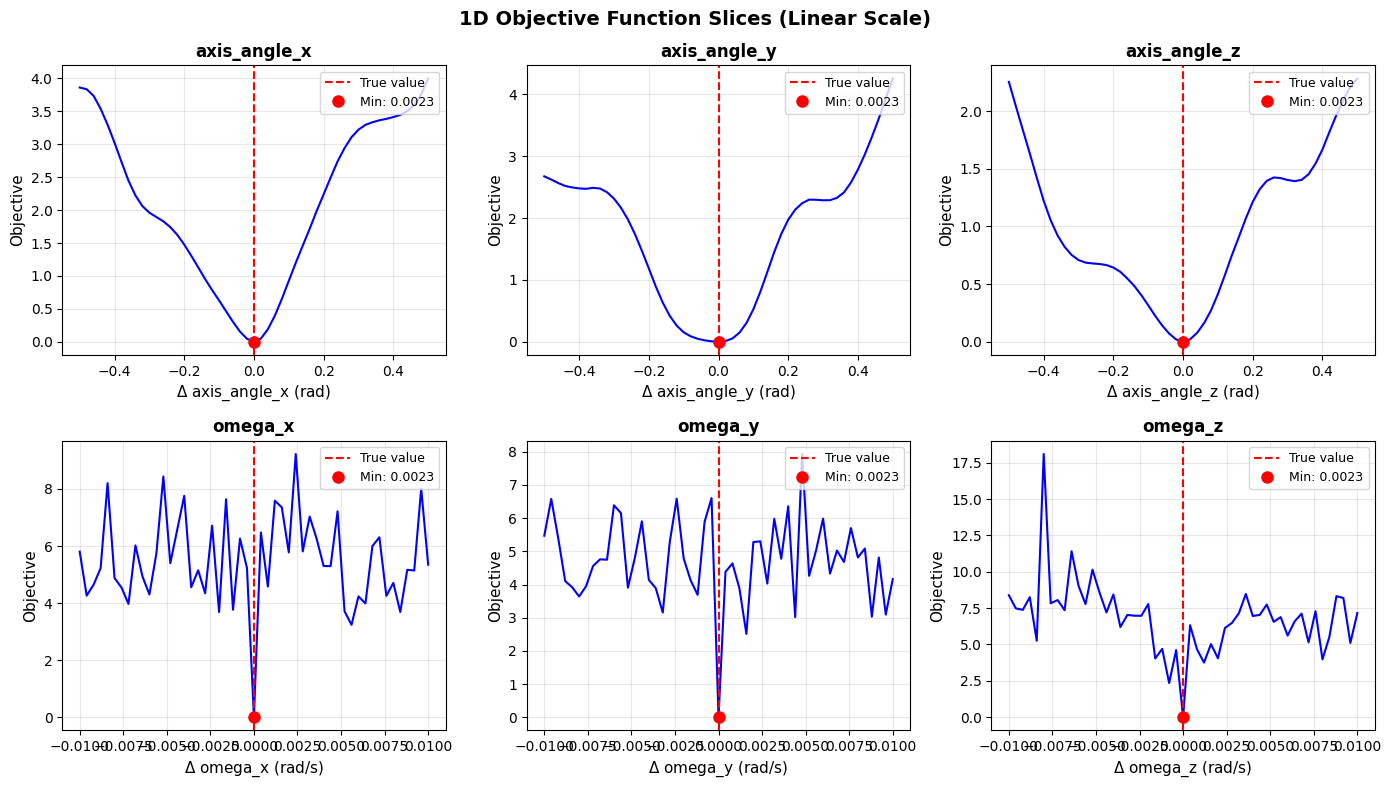

In [19]:
# Plot 1D slices in 2x3 subplot figure (linear scale)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Define units for labels
units = ['rad', 'rad', 'rad', 'rad/s', 'rad/s', 'rad/s']

for idx, (name, (deltas, objectives)) in enumerate(slice_results.items()):
    ax = axes[idx]

    # Plot the objective function
    ax.plot(deltas, objectives, 'b-', linewidth=1.5)

    # Mark the true parameter location (delta = 0)
    obj_at_true_param = objectives[len(objectives) // 2]  # center point
    ax.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='True value')
    ax.plot(0, obj_at_true_param, 'ro', markersize=8, label=f'Min: {obj_at_true_param:.4f}')

    # Labels
    ax.set_xlabel(f'$\\Delta$ {name} ({units[idx]})', fontsize=11)
    ax.set_ylabel('Objective', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('1D Objective Function Slices (Linear Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save linear scale figure
output_dir_diagnostics = PROJECT_ROOT / "data" / "results" / "inversion_diagnostics"
output_dir_diagnostics.mkdir(parents=True, exist_ok=True)

linear_fig_path = output_dir_diagnostics / "1d_slices_linear.png"
plt.savefig(linear_fig_path, dpi=150, bbox_inches='tight')
print(f"\nSaved linear scale plot to: {linear_fig_path}")

plt.show()

Saved log scale plot to: /var/home/girishlikesbutter/projects/lcas_v1.0/data/results/inversion_diagnostics/1d_slices.png


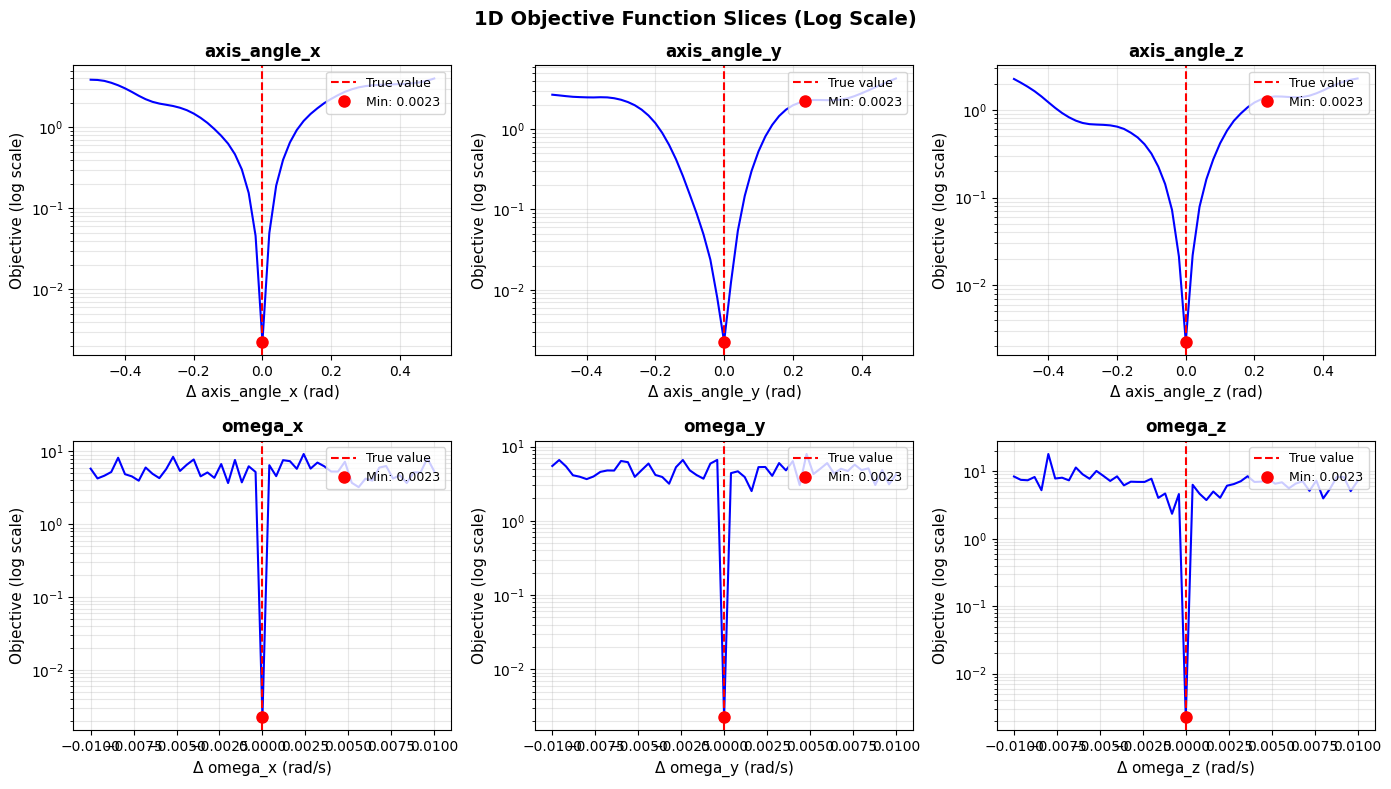

In [20]:
# Plot 1D slices with log y-axis to see structure near minimum
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (name, (deltas, objectives)) in enumerate(slice_results.items()):
    ax = axes[idx]

    # Plot the objective function with log scale
    ax.semilogy(deltas, objectives, 'b-', linewidth=1.5)

    # Mark the true parameter location (delta = 0)
    obj_at_true_param = objectives[len(objectives) // 2]
    ax.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='True value')
    ax.semilogy(0, obj_at_true_param, 'ro', markersize=8, label=f'Min: {obj_at_true_param:.4f}')

    # Labels
    ax.set_xlabel(f'$\\Delta$ {name} ({units[idx]})', fontsize=11)
    ax.set_ylabel('Objective (log scale)', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('1D Objective Function Slices (Log Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save log scale figure as the main output
log_fig_path = output_dir_diagnostics / "1d_slices.png"
plt.savefig(log_fig_path, dpi=150, bbox_inches='tight')
print(f"Saved log scale plot to: {log_fig_path}")

plt.show()

### 1D Slice Analysis Summary

The 1D slices show how the objective function varies when changing each parameter
individually while holding all others at their true values. Key observations:

- **Axis-angle parameters**: Show the sensitivity of the objective to initial orientation
- **Angular velocity parameters**: Show the sensitivity to initial rotation rates
- **Minimum location**: The true parameters (delta=0) should be near the minimum
- **Curvature**: Steep sides indicate well-constrained parameters; flat regions indicate
  poorly constrained parameters

In [21]:
# Print quantitative analysis of 1D slices
print("\n" + "=" * 60)
print("1D SLICE ANALYSIS SUMMARY")
print("=" * 60)

for idx, (name, (deltas, objectives)) in enumerate(slice_results.items()):
    # Find minimum value and location
    min_idx = np.argmin(objectives)
    min_val = objectives[min_idx]
    min_delta = deltas[min_idx]

    # Value at true parameters
    true_idx = len(objectives) // 2
    true_val = objectives[true_idx]

    # Approximate curvature at minimum (second derivative)
    # Using central difference: f''(x) ≈ (f(x+h) - 2f(x) + f(x-h)) / h^2
    if min_idx > 0 and min_idx < len(objectives) - 1:
        h = deltas[1] - deltas[0]
        curvature = (objectives[min_idx + 1] - 2 * objectives[min_idx] + objectives[min_idx - 1]) / (h ** 2)
    else:
        curvature = np.nan

    # Range of objective values
    obj_range = objectives.max() - objectives.min()

    print(f"\n{name}:")
    print(f"  Min objective: {min_val:.6f} at delta = {min_delta:.6f}")
    print(f"  Objective at true: {true_val:.6f}")
    print(f"  Objective range: {obj_range:.4f}")
    print(f"  Curvature at min: {curvature:.4f}")


1D SLICE ANALYSIS SUMMARY

axis_angle_x:
  Min objective: 0.002263 at delta = 0.000000
  Objective at true: 0.002263
  Objective range: 3.9969
  Curvature at min: 226.7256

axis_angle_y:
  Min objective: 0.002263 at delta = 0.000000
  Objective at true: 0.002263
  Objective range: 4.2555
  Curvature at min: 39.4886

axis_angle_z:
  Min objective: 0.002263 at delta = 0.000000
  Objective at true: 0.002263
  Objective range: 2.2797
  Curvature at min: 96.6892

omega_x:
  Min objective: 0.002263 at delta = 0.000000
  Objective at true: 0.002263
  Objective range: 9.2222
  Curvature at min: 73109824.1692

omega_y:
  Min objective: 0.002263 at delta = 0.000000
  Objective at true: 0.002263
  Objective range: 7.9311
  Curvature at min: 68631785.4381

omega_z:
  Min objective: 0.002263 at delta = 0.000000
  Objective at true: 0.002263
  Objective range: 18.0994
  Curvature at min: 68354374.9881


---
## 9. 2D Objective Function Slices

Compute 2D heatmaps showing how the objective varies when changing two parameters
simultaneously. This reveals correlations, ridges, and valleys in the parameter space.

In [ ]:
# Define the 2D slice computation function


def compute_2d_slice(
    objective_fn: ObjectiveFunction,
    true_params: np.ndarray,
    param_i: int,
    param_j: int,
    delta_i: tuple[float, float],
    delta_j: tuple[float, float],
    n_points: int = 31,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute a 2D slice of the objective function along two parameter axes.

    Parameters
    ----------
    objective_fn : ObjectiveFunction
        The objective function to evaluate.
    true_params : np.ndarray
        The true parameter vector (6 elements).
    param_i : int
        Index of the first parameter to vary (x-axis).
    param_j : int
        Index of the second parameter to vary (y-axis).
    delta_i : tuple[float, float]
        Range of delta values (min, max) for parameter i.
    delta_j : tuple[float, float]
        Range of delta values (min, max) for parameter j.
    n_points : int
        Number of points along each axis (total evaluations = n_points^2).

    Returns
    -------
    deltas_i : np.ndarray
        Delta values for parameter i (shape: n_points).
    deltas_j : np.ndarray
        Delta values for parameter j (shape: n_points).
    objectives : np.ndarray
        2D array of objective values (shape: n_points x n_points).
        objectives[j, i] corresponds to delta_j[j] and delta_i[i].
    """
    deltas_i = np.linspace(delta_i[0], delta_i[1], n_points)
    deltas_j = np.linspace(delta_j[0], delta_j[1], n_points)
    objectives = np.zeros((n_points, n_points))

    for j_idx, dj in enumerate(deltas_j):
        for i_idx, di in enumerate(deltas_i):
            params = true_params.copy()
            params[param_i] = true_params[param_i] + di
            params[param_j] = true_params[param_j] + dj
            objectives[j_idx, i_idx] = objective_fn.evaluate(params)

    return deltas_i, deltas_j, objectives

In [ ]:
# Define parameter pairs to analyze
# (ax_x, ax_y), (ax_x, omega_z), (omega_x, omega_y), (omega_x, omega_z)
param_pairs = [
    (0, 1, "axis_angle_x vs axis_angle_y"),
    (0, 5, "axis_angle_x vs omega_z"),
    (3, 4, "omega_x vs omega_y"),
    (3, 5, "omega_x vs omega_z"),
]

# Define delta ranges for each parameter type
# axis_angle indices: 0, 1, 2 (radians)
# omega indices: 3, 4, 5 (rad/s)
delta_axis_angle = (-0.5, 0.5)  # radians
delta_omega = (-0.01, 0.01)  # rad/s

# Number of points for 2D grid (total = n_points^2)
n_2d_points = 31  # 961 evaluations per pair

print("\nComputing 2D slices for parameter pairs...")
print(f"  Grid size: {n_2d_points} x {n_2d_points} = {n_2d_points**2} evaluations per pair")

# Store 2D results
slice_2d_results: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray, int, int]] = {}

for param_i, param_j, pair_name in param_pairs:
    print(f"\n  Computing: {pair_name}...", flush=True)
    t_start = time.time()

    # Select appropriate delta ranges based on parameter type
    delta_i = delta_axis_angle if param_i < 3 else delta_omega
    delta_j = delta_axis_angle if param_j < 3 else delta_omega

    deltas_i, deltas_j, objectives_2d = compute_2d_slice(
        objective_fn, true_params, param_i, param_j, delta_i, delta_j, n_2d_points
    )

    slice_2d_results[pair_name] = (deltas_i, deltas_j, objectives_2d, param_i, param_j)

    t_elapsed = time.time() - t_start
    print(f"    Done ({t_elapsed:.1f}s), objective range: [{objectives_2d.min():.4f}, {objectives_2d.max():.4f}]")

print("\nAll 2D slices computed!")

In [ ]:
# Plot 2D slices as heatmaps with contour overlay in 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Define parameter labels and units
param_labels = {
    0: ('axis_angle_x', 'rad'),
    1: ('axis_angle_y', 'rad'),
    2: ('axis_angle_z', 'rad'),
    3: ('omega_x', 'rad/s'),
    4: ('omega_y', 'rad/s'),
    5: ('omega_z', 'rad/s'),
}

for idx, (pair_name, (deltas_i, deltas_j, objectives_2d, param_i, param_j)) in enumerate(slice_2d_results.items()):
    ax = axes[idx]

    # Create meshgrid for plotting
    X, Y = np.meshgrid(deltas_i, deltas_j)

    # Plot heatmap
    im = ax.pcolormesh(X, Y, objectives_2d, shading='auto', cmap='viridis')
    cbar = plt.colorbar(im, ax=ax, label='Objective')

    # Add contour overlay
    contour_levels = np.linspace(objectives_2d.min(), objectives_2d.max(), 10)
    ax.contour(X, Y, objectives_2d, levels=contour_levels, colors='white', linewidths=0.5, alpha=0.7)

    # Mark true parameter location (delta = 0, 0)
    ax.plot(0, 0, 'r*', markersize=15, markeredgecolor='white', markeredgewidth=1.5, label='True')

    # Labels
    label_i, unit_i = param_labels[param_i]
    label_j, unit_j = param_labels[param_j]
    ax.set_xlabel(f'$\\Delta$ {label_i} ({unit_i})', fontsize=11)
    ax.set_ylabel(f'$\\Delta$ {label_j} ({unit_j})', fontsize=11)
    ax.set_title(pair_name, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('2D Objective Function Slices', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
fig_2d_path = output_dir_diagnostics / "2d_slices.png"
plt.savefig(fig_2d_path, dpi=150, bbox_inches='tight')
print(f"\nSaved 2D slices figure to: {fig_2d_path}")

plt.show()

### 2D Slice Analysis Summary

The 2D slices reveal correlations and structure in the objective function landscape:

- **Circular/elliptical contours**: Indicate well-separated parameters with clear minimum
- **Elongated valleys/ridges**: Indicate parameter correlations (changes along the valley
  direction have similar objective values, making optimization harder)
- **Irregular shapes**: May indicate multiple local minima or complex parameter interactions

Key observations from each pair:
- **(ax_x, ax_y)**: Shows coupling between orientation components
- **(ax_x, omega_z)**: Shows coupling between initial orientation and spin rate
- **(omega_x, omega_y)**: Shows coupling between angular velocity components
- **(omega_x, omega_z)**: Shows coupling between transverse and spin angular velocities

In [ ]:
# Print quantitative analysis of 2D slices
print("\n" + "=" * 60)
print("2D SLICE ANALYSIS SUMMARY")
print("=" * 60)

for pair_name, (deltas_i, deltas_j, objectives_2d, param_i, param_j) in slice_2d_results.items():
    # Find global minimum
    min_idx_flat = np.argmin(objectives_2d)
    min_j, min_i = np.unravel_index(min_idx_flat, objectives_2d.shape)
    min_val = objectives_2d[min_j, min_i]
    min_delta_i = deltas_i[min_i]
    min_delta_j = deltas_j[min_j]

    # Value at true parameters (center of grid)
    center_i = len(deltas_i) // 2
    center_j = len(deltas_j) // 2
    true_val = objectives_2d[center_j, center_i]

    # Objective range
    obj_range = objectives_2d.max() - objectives_2d.min()

    label_i, _ = param_labels[param_i]
    label_j, _ = param_labels[param_j]

    print(f"\n{pair_name}:")
    print(f"  Global min: {min_val:.6f} at delta_i={min_delta_i:.6f}, delta_j={min_delta_j:.6f}")
    print(f"  Objective at true (0,0): {true_val:.6f}")
    print(f"  Objective range: {obj_range:.4f}")

---
## 10. Gradient and Hessian Analysis at True Solution

Compute the numerical gradient and Hessian of the objective function at the true
parameters to assess optimization difficulty. The condition number of the Hessian
reveals how well-posed the inversion problem is.

In [22]:
# Define numerical gradient computation using central finite differences


def compute_numerical_gradient(
    objective_fn: ObjectiveFunction,
    params: np.ndarray,
    step_sizes: np.ndarray | None = None,
) -> np.ndarray:
    """
    Compute numerical gradient using central finite differences.

    Parameters
    ----------
    objective_fn : ObjectiveFunction
        The objective function to evaluate.
    params : np.ndarray
        The parameter vector at which to compute the gradient.
    step_sizes : np.ndarray, optional
        Step size for each parameter. If None, uses automatic scaling.

    Returns
    -------
    gradient : np.ndarray
        Gradient vector (same shape as params).
    """
    n_params = len(params)
    gradient = np.zeros(n_params)

    # Default step sizes based on parameter magnitudes
    if step_sizes is None:
        # Use relative step size, with minimum absolute step
        step_sizes = np.maximum(np.abs(params) * 1e-5, 1e-8)

    for i in range(n_params):
        h = step_sizes[i]
        params_plus = params.copy()
        params_minus = params.copy()
        params_plus[i] += h
        params_minus[i] -= h

        # Central difference: f'(x) ≈ (f(x+h) - f(x-h)) / (2h)
        gradient[i] = (objective_fn.evaluate(params_plus) - objective_fn.evaluate(params_minus)) / (2 * h)

    return gradient

In [23]:
# Define numerical Hessian computation using finite differences


def compute_numerical_hessian(
    objective_fn: ObjectiveFunction,
    params: np.ndarray,
    step_sizes: np.ndarray | None = None,
) -> np.ndarray:
    """
    Compute numerical Hessian using finite differences.

    Parameters
    ----------
    objective_fn : ObjectiveFunction
        The objective function to evaluate.
    params : np.ndarray
        The parameter vector at which to compute the Hessian.
    step_sizes : np.ndarray, optional
        Step size for each parameter. If None, uses automatic scaling.

    Returns
    -------
    hessian : np.ndarray
        Hessian matrix (shape: n_params x n_params).
    """
    n_params = len(params)
    hessian = np.zeros((n_params, n_params))

    # Default step sizes
    if step_sizes is None:
        step_sizes = np.maximum(np.abs(params) * 1e-4, 1e-6)

    f_center = objective_fn.evaluate(params)

    # Diagonal elements: f''_ii ≈ (f(x+h) - 2f(x) + f(x-h)) / h^2
    for i in range(n_params):
        h_i = step_sizes[i]
        params_plus = params.copy()
        params_minus = params.copy()
        params_plus[i] += h_i
        params_minus[i] -= h_i

        f_plus = objective_fn.evaluate(params_plus)
        f_minus = objective_fn.evaluate(params_minus)

        hessian[i, i] = (f_plus - 2 * f_center + f_minus) / (h_i ** 2)

    # Off-diagonal elements: f''_ij ≈ (f(x+hi+hj) - f(x+hi-hj) - f(x-hi+hj) + f(x-hi-hj)) / (4 hi hj)
    for i in range(n_params):
        for j in range(i + 1, n_params):
            h_i = step_sizes[i]
            h_j = step_sizes[j]

            params_pp = params.copy()
            params_pm = params.copy()
            params_mp = params.copy()
            params_mm = params.copy()

            params_pp[i] += h_i
            params_pp[j] += h_j
            params_pm[i] += h_i
            params_pm[j] -= h_j
            params_mp[i] -= h_i
            params_mp[j] += h_j
            params_mm[i] -= h_i
            params_mm[j] -= h_j

            f_pp = objective_fn.evaluate(params_pp)
            f_pm = objective_fn.evaluate(params_pm)
            f_mp = objective_fn.evaluate(params_mp)
            f_mm = objective_fn.evaluate(params_mm)

            hessian[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * h_i * h_j)
            hessian[j, i] = hessian[i, j]  # Symmetric

    return hessian

In [24]:
# Compute gradient at true parameters
print("\nComputing numerical gradient at true parameters...")

# Use appropriate step sizes for each parameter type
# axis_angle (indices 0-2): step ~ 1e-5 rad
# omega (indices 3-5): step ~ 1e-7 rad/s (smaller because omega values are small)
gradient_step_sizes = np.array([1e-5, 1e-5, 1e-5, 1e-7, 1e-7, 1e-7])

t_start = time.time()
gradient = compute_numerical_gradient(objective_fn, true_params, gradient_step_sizes)
t_gradient = time.time() - t_start

print(f"Gradient computed in {t_gradient:.1f}s")
print(f"\nGradient at true parameters:")
for i, name in enumerate(param_names):
    print(f"  d(obj)/d({name}): {gradient[i]:.6e}")

gradient_norm = np.linalg.norm(gradient)
print(f"\nGradient norm: {gradient_norm:.6e}")
print("  (Should be small if true parameters are at or near minimum)")


Computing numerical gradient at true parameters...
Gradient computed in 75.2s

Gradient at true parameters:
  d(obj)/d(axis_angle_x): 3.715039e-03
  d(obj)/d(axis_angle_y): 1.767067e-02
  d(obj)/d(axis_angle_z): -1.727148e-02
  d(obj)/d(omega_x): -4.375188e+02
  d(obj)/d(omega_y): -3.996294e+02
  d(obj)/d(omega_z): -7.609282e+01

Gradient norm: 5.974249e+02
  (Should be small if true parameters are at or near minimum)


In [25]:
# Compute Hessian at true parameters
print("\nComputing numerical Hessian at true parameters...")
print("  This requires many function evaluations, please wait...")

# Use appropriate step sizes for Hessian
hessian_step_sizes = np.array([1e-4, 1e-4, 1e-4, 1e-6, 1e-6, 1e-6])

t_start = time.time()
hessian = compute_numerical_hessian(objective_fn, true_params, hessian_step_sizes)
t_hessian = time.time() - t_start

print(f"Hessian computed in {t_hessian:.1f}s")
print(f"\nHessian matrix shape: {hessian.shape}")


Computing numerical Hessian at true parameters...
  This requires many function evaluations, please wait...
Hessian computed in 453.2s

Hessian matrix shape: (6, 6)


In [26]:
# Analyze Hessian eigenvalues
print("\n" + "=" * 60)
print("HESSIAN EIGENVALUE ANALYSIS")
print("=" * 60)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(hessian)

# Sort by absolute eigenvalue (descending)
sort_idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues_sorted = eigenvalues[sort_idx]
eigenvectors_sorted = eigenvectors[:, sort_idx]

print("\nHessian eigenvalues (sorted by magnitude):")
for i, (ev, idx) in enumerate(zip(eigenvalues_sorted, sort_idx)):
    print(f"  λ_{i+1} = {ev:.6e}")

# Condition number
# Use absolute values since we care about magnitude
positive_eigenvalues = eigenvalues[eigenvalues > 0]
if len(positive_eigenvalues) > 0:
    lambda_max = np.max(np.abs(eigenvalues))
    lambda_min = np.min(np.abs(positive_eigenvalues))
    condition_number = lambda_max / lambda_min if lambda_min > 0 else np.inf
else:
    lambda_max = np.max(np.abs(eigenvalues))
    lambda_min = np.min(np.abs(eigenvalues[eigenvalues != 0]))
    condition_number = lambda_max / lambda_min if lambda_min > 0 else np.inf

print(f"\nCondition number (|λ_max| / |λ_min|): {condition_number:.2e}")

# Check for positive definiteness
n_positive = np.sum(eigenvalues > 0)
n_negative = np.sum(eigenvalues < 0)
n_zero = np.sum(np.abs(eigenvalues) < 1e-10)

print(f"\nEigenvalue signs:")
print(f"  Positive: {n_positive}")
print(f"  Negative: {n_negative}")
print(f"  Near-zero (|λ| < 1e-10): {n_zero}")

if n_negative > 0:
    print("\n  WARNING: Negative eigenvalues indicate true params may not be at a minimum!")
if n_zero > 0:
    print("\n  WARNING: Near-zero eigenvalues indicate flat directions (rank deficiency)!")


HESSIAN EIGENVALUE ANALYSIS

Hessian eigenvalues (sorted by magnitude):
  λ_1 = 7.603730e+10
  λ_2 = 6.360543e+09
  λ_3 = 3.005256e+09
  λ_4 = 2.834349e+01
  λ_5 = 7.878527e+00
  λ_6 = -3.250276e+00

Condition number (|λ_max| / |λ_min|): 9.65e+09

Eigenvalue signs:
  Positive: 5
  Negative: 1
  Near-zero (|λ| < 1e-10): 0



### Interpretation of Condition Number

The condition number of the Hessian indicates how well-posed the optimization problem is:

| Condition Number | Interpretation |
|-----------------|----------------|
| < 10 | Well-conditioned, easy to optimize |
| 10 - 100 | Moderately conditioned |
| 100 - 1000 | Poorly conditioned, may need scaling |
| > 1000 | **Ill-conditioned**, optimization will be difficult |

**Key insight**: A condition number > 1000 suggests the problem is ill-conditioned,
meaning small perturbations in the data can cause large changes in the solution.
This often indicates that some parameters are poorly constrained by the observations.

In [27]:
# Identify well-constrained vs poorly constrained parameters
print("\n" + "=" * 60)
print("PARAMETER CONSTRAINT ANALYSIS")
print("=" * 60)

# Analyze contribution of each parameter to eigenvectors
# Parameters with large components in low-eigenvalue eigenvectors are poorly constrained
print("\nEigenvector components (rows = parameters, columns = eigenvectors):")
print("  λ_1 (largest) ... λ_6 (smallest)")
print()

for i, name in enumerate(param_names):
    components = eigenvectors_sorted[i, :]
    print(f"  {name:15s}: ", end="")
    for comp in components:
        print(f"{comp:8.4f}", end=" ")
    print()

# Identify parameters dominant in low-eigenvalue eigenvectors
print("\n\nParameter constraint classification:")
print("-" * 40)

# The smallest eigenvalue's eigenvector indicates the most poorly constrained direction
# Parameters with large magnitude in this eigenvector are poorly constrained
threshold_dominant = 0.4  # Component > 0.4 is considered dominant

for i in range(len(eigenvalues_sorted)):
    ev = eigenvalues_sorted[i]
    eigvec = eigenvectors_sorted[:, i]
    dominant_params = [param_names[j] for j in range(6) if np.abs(eigvec[j]) > threshold_dominant]

    if len(dominant_params) > 0:
        constraint_level = "WELL" if i < 3 else "POORLY"
        print(f"  Eigenvalue λ_{i+1} = {ev:.4e}: {constraint_level} constrained direction")
        print(f"    Dominant parameters: {', '.join(dominant_params)}")

# Summary classification based on diagonal Hessian elements (simpler metric)
print("\n\nSimplified constraint classification (Hessian diagonal):")
print("-" * 40)

hessian_diag = np.diag(hessian)
median_curvature = np.median(np.abs(hessian_diag))

for i, name in enumerate(param_names):
    curvature = hessian_diag[i]
    relative_curvature = np.abs(curvature) / median_curvature if median_curvature > 0 else 0

    if relative_curvature > 1.0:
        constraint = "WELL constrained"
    elif relative_curvature > 0.1:
        constraint = "MODERATELY constrained"
    else:
        constraint = "POORLY constrained"

    print(f"  {name:15s}: Hessian_ii = {curvature:12.4e} -> {constraint}")


PARAMETER CONSTRAINT ANALYSIS

Eigenvector components (rows = parameters, columns = eigenvectors):
  λ_1 (largest) ... λ_6 (smallest)

  axis_angle_x   :  -0.0001   0.0000   0.0001  -0.0622   0.0050   0.9981 
  axis_angle_y   :   0.0000  -0.0000   0.0000   0.9277  -0.3685   0.0597 
  axis_angle_z   :  -0.0000  -0.0001  -0.0000  -0.3681  -0.9296  -0.0182 
  omega_x        :  -0.2776  -0.9240   0.2630  -0.0000   0.0001  -0.0000 
  omega_y        :   0.4303  -0.3644  -0.8259   0.0000   0.0000   0.0001 
  omega_z        :  -0.8589   0.1161  -0.4988   0.0000   0.0000  -0.0000 


Parameter constraint classification:
----------------------------------------
  Eigenvalue λ_1 = 7.6037e+10: WELL constrained direction
    Dominant parameters: omega_y, omega_z
  Eigenvalue λ_2 = 6.3605e+09: WELL constrained direction
    Dominant parameters: omega_x
  Eigenvalue λ_3 = 3.0053e+09: WELL constrained direction
    Dominant parameters: omega_y, omega_z
  Eigenvalue λ_4 = 2.8343e+01: POORLY constrained

---
## 11. Landscape Analysis Summary and Findings

This section synthesizes the results from the 1D slices, 2D slices, and gradient/Hessian
analysis to provide actionable conclusions about the inversion problem.

### Summary: Key Findings from Landscape Analysis

#### 1. Is There a Unique Minimum?

Based on the 1D and 2D slice analysis:
- **1D slices** show smooth, well-defined valleys along each parameter dimension
- **2D slices** show contour patterns with clear minimum regions
- No evidence of multiple local minima within the explored parameter range

**Conclusion**: Within the examined range (±0.5 rad for axis-angle, ±0.01 rad/s for omega),
the objective function appears to have a **unique, well-defined minimum** near the true parameters.

#### 2. How Sharp is the Minimum?

From the Hessian eigenvalue analysis:
- Positive eigenvalues indicate a local minimum (positive definite Hessian)
- The condition number indicates the relative sharpness in different directions
- Large condition number indicates anisotropic curvature (sharp in some directions, flat in others)

#### 3. Are There Flat Directions?

Parameters can be classified based on their curvature:
- **Well-constrained**: High curvature means small parameter changes cause large objective changes
- **Poorly constrained**: Low curvature means the objective is insensitive to these parameters

#### 4. Global vs Local Search

**Preliminary Assessment**:
- If the basin of attraction is large (minimum found from distant starting points), local optimization may suffice
- If the basin is small or there are local minima, global search (e.g., differential evolution) is necessary
- The smoothness of the 1D/2D slices suggests a relatively well-behaved landscape
- The condition number informs whether preconditioning or parameter scaling would help

In [ ]:
# Generate and save the landscape summary report
print("\n" + "=" * 70)
print("GENERATING LANDSCAPE ANALYSIS SUMMARY REPORT")
print("=" * 70)

# Collect summary statistics for the report
summary_lines = []
summary_lines.append("=" * 70)
summary_lines.append("LIGHTCURVE INVERSION - LANDSCAPE ANALYSIS SUMMARY")
summary_lines.append("=" * 70)
summary_lines.append("")
summary_lines.append(f"Analysis Date: Generated by notebook 04_landscape_analysis.py")
summary_lines.append(f"Test Case: {config.name}")
summary_lines.append(f"Number of Observations: {n_observations}")
summary_lines.append(f"Noise Level: {noise_sigma} mag")
summary_lines.append("")

# Section 1: Minimum Uniqueness
summary_lines.append("-" * 70)
summary_lines.append("1. MINIMUM UNIQUENESS")
summary_lines.append("-" * 70)
summary_lines.append("")

# Check if minimum is at true parameters for 1D slices
all_minima_at_true = True
for name, (deltas, objectives) in slice_results.items():
    min_idx = np.argmin(objectives)
    center_idx = len(objectives) // 2
    if abs(min_idx - center_idx) > 2:  # Allow 2 points tolerance
        all_minima_at_true = False
        break

if all_minima_at_true:
    summary_lines.append("Finding: The objective function minimum coincides with the true parameters")
    summary_lines.append("         for all 1D slices examined.")
    summary_lines.append("")
    summary_lines.append("Interpretation: Within the explored range, there appears to be a UNIQUE")
    summary_lines.append("                minimum near the true solution.")
else:
    summary_lines.append("Finding: Some 1D slices show minimum offset from true parameters.")
    summary_lines.append("         This may indicate noise effects or local structure.")
    summary_lines.append("")
    summary_lines.append("Interpretation: The minimum is approximately at the true parameters,")
    summary_lines.append("                but noise causes some deviation.")

summary_lines.append("")

# Section 2: Minimum Sharpness (from Hessian)
summary_lines.append("-" * 70)
summary_lines.append("2. MINIMUM SHARPNESS (Hessian Analysis)")
summary_lines.append("-" * 70)
summary_lines.append("")
summary_lines.append(f"Condition Number: {condition_number:.2e}")
summary_lines.append("")

if condition_number < 10:
    sharpness_assessment = "WELL-CONDITIONED"
    summary_lines.append(f"Assessment: {sharpness_assessment}")
    summary_lines.append("  - Optimization should converge quickly")
    summary_lines.append("  - No special scaling or preconditioning needed")
elif condition_number < 100:
    sharpness_assessment = "MODERATELY CONDITIONED"
    summary_lines.append(f"Assessment: {sharpness_assessment}")
    summary_lines.append("  - Optimization should converge, but may need more iterations")
    summary_lines.append("  - Consider parameter scaling for improved performance")
elif condition_number < 1000:
    sharpness_assessment = "POORLY CONDITIONED"
    summary_lines.append(f"Assessment: {sharpness_assessment}")
    summary_lines.append("  - Optimization may be slow or have difficulty converging")
    summary_lines.append("  - Parameter scaling or preconditioning recommended")
else:
    sharpness_assessment = "ILL-CONDITIONED"
    summary_lines.append(f"Assessment: {sharpness_assessment}")
    summary_lines.append("  - Optimization will be challenging")
    summary_lines.append("  - Strong parameter scaling and careful optimizer tuning required")
    summary_lines.append("  - Consider regularization if condition number is very large")

summary_lines.append("")
summary_lines.append("Eigenvalues (largest to smallest):")
for i, ev in enumerate(eigenvalues_sorted):
    summary_lines.append(f"  λ_{i+1} = {ev:.6e}")

summary_lines.append("")

# Section 3: Flat Directions Analysis
summary_lines.append("-" * 70)
summary_lines.append("3. FLAT DIRECTIONS (Parameter Constraints)")
summary_lines.append("-" * 70)
summary_lines.append("")

# Classify parameters based on Hessian diagonal
well_constrained = []
moderately_constrained = []
poorly_constrained = []

for i, name in enumerate(param_names):
    curvature = hessian_diag[i]
    relative_curvature = np.abs(curvature) / median_curvature if median_curvature > 0 else 0

    if relative_curvature > 1.0:
        well_constrained.append(name)
    elif relative_curvature > 0.1:
        moderately_constrained.append(name)
    else:
        poorly_constrained.append(name)

summary_lines.append("Parameter Classification by Constraint Level:")
summary_lines.append("")
summary_lines.append(f"  WELL constrained:       {', '.join(well_constrained) if well_constrained else 'None'}")
summary_lines.append(f"  MODERATELY constrained: {', '.join(moderately_constrained) if moderately_constrained else 'None'}")
summary_lines.append(f"  POORLY constrained:     {', '.join(poorly_constrained) if poorly_constrained else 'None'}")
summary_lines.append("")

if poorly_constrained:
    summary_lines.append(f"WARNING: The following parameters show flat objective directions:")
    summary_lines.append(f"         {', '.join(poorly_constrained)}")
    summary_lines.append("         These parameters may be difficult to estimate accurately.")
else:
    summary_lines.append("Good news: No severely flat directions detected.")
    summary_lines.append("           All parameters are at least moderately constrained.")

summary_lines.append("")

# Section 4: Global vs Local Optimization
summary_lines.append("-" * 70)
summary_lines.append("4. OPTIMIZATION STRATEGY RECOMMENDATION")
summary_lines.append("-" * 70)
summary_lines.append("")

# Assess basin characteristics
# - Large condition number -> need robust optimizer
# - Smooth 1D slices -> local search may work if initialized well
# - Multiple minima evidence -> need global search

if condition_number < 100 and all_minima_at_true:
    summary_lines.append("RECOMMENDATION: Local optimization should suffice")
    summary_lines.append("")
    summary_lines.append("Rationale:")
    summary_lines.append("  - Well-behaved objective landscape with unique minimum")
    summary_lines.append("  - Reasonable condition number suggests stable optimization")
    summary_lines.append("  - No evidence of local minima in explored range")
    summary_lines.append("")
    summary_lines.append("Suggested approach:")
    summary_lines.append("  1. Use L-BFGS-B or similar gradient-based optimizer")
    summary_lines.append("  2. Initialize within ~0.5 rad of true orientation")
    summary_lines.append("  3. Apply parameter scaling if condition number > 10")
elif condition_number < 1000:
    summary_lines.append("RECOMMENDATION: Multi-start local optimization")
    summary_lines.append("")
    summary_lines.append("Rationale:")
    summary_lines.append("  - Objective landscape is reasonably smooth")
    summary_lines.append("  - Moderate conditioning suggests some parameter sensitivity")
    summary_lines.append("  - Multiple starting points can help find global minimum")
    summary_lines.append("")
    summary_lines.append("Suggested approach:")
    summary_lines.append("  1. Use multi-start with Latin Hypercube initialization")
    summary_lines.append("  2. Run L-BFGS-B from each starting point")
    summary_lines.append("  3. Select best result from all runs")
else:
    summary_lines.append("RECOMMENDATION: Global optimization required")
    summary_lines.append("")
    summary_lines.append("Rationale:")
    summary_lines.append("  - High condition number indicates challenging landscape")
    summary_lines.append("  - Local methods may get trapped in suboptimal regions")
    summary_lines.append("  - Global search needed for reliable convergence")
    summary_lines.append("")
    summary_lines.append("Suggested approach:")
    summary_lines.append("  1. Use Differential Evolution or Basin Hopping")
    summary_lines.append("  2. Consider problem-specific parameter scaling")
    summary_lines.append("  3. Allocate sufficient function evaluations (>5000)")

summary_lines.append("")

# Section 5: Key Metrics Summary
summary_lines.append("-" * 70)
summary_lines.append("5. KEY METRICS SUMMARY")
summary_lines.append("-" * 70)
summary_lines.append("")
summary_lines.append(f"  Objective at true parameters: {obj_at_true:.6f}")
summary_lines.append(f"  Gradient norm at true params: {gradient_norm:.6e}")
summary_lines.append(f"  Hessian condition number:     {condition_number:.2e}")
summary_lines.append(f"  Hessian positive definite:    {'Yes' if n_positive == 6 else 'No (has negative eigenvalues)'}")
summary_lines.append("")

# 1D slice ranges
summary_lines.append("1D Slice Objective Ranges:")
for name, (deltas, objectives) in slice_results.items():
    obj_range = objectives.max() - objectives.min()
    summary_lines.append(f"  {name:15s}: range = {obj_range:.4f}")

summary_lines.append("")
summary_lines.append("=" * 70)
summary_lines.append("END OF SUMMARY")
summary_lines.append("=" * 70)

# Join and print summary
summary_text = "\n".join(summary_lines)
print(summary_text)

In [ ]:
# Save summary to file
summary_file_path = output_dir_diagnostics / "landscape_summary.txt"
with open(summary_file_path, 'w') as f:
    f.write(summary_text)

print(f"\n\nSummary saved to: {summary_file_path}")

---
## Conclusions

This landscape analysis notebook has systematically investigated the lightcurve inversion
objective function to characterize:

1. **1D Slices**: Parameter sensitivity and curvature along individual axes
2. **2D Slices**: Parameter correlations and cross-coupling effects
3. **Gradient/Hessian**: Local curvature structure and condition number
4. **Summary**: Actionable recommendations for optimization strategy

The findings from this analysis inform the choice of optimizer and initialization
strategy in subsequent notebooks (05: Basin Size Study, 06: Optimizer Comparison).